MNIST Multi Class Classification----90% +Acuracy

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = "Cuda" if torch.cuda.is_available()else"cpu"
print("using device",device)

using device cpu


In [3]:
from torchvision import transforms

transform = transforms.ToTensor()
train_data = MNIST(root="data",train=True,download=True,transform=transform)
test_data = MNIST(root="data",train=False,download=True,transform=transform)

100%|██████████| 9.91M/9.91M [00:26<00:00, 377kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 53.4kB/s]
100%|██████████| 1.65M/1.65M [00:09<00:00, 169kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.27MB/s]


In [4]:
train_loader = DataLoader(train_data,batch_size=64,shuffle=True)
test_loader = DataLoader(test_data,batch_size=64,shuffle=False)

In [5]:
class DigitModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(28*28,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.net(x)

In [6]:
model = DigitModel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
epochs = 5
for epoch in range(epochs):
  model.train()
  total_loss = 0
  for image,labels in train_loader:
    images = image.view(image.size(0),-1).to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = loss_fn(outputs,labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  print(f"Epoch{epoch+1},Loss:{total_loss/len(train_loader):.4f}")

Epoch1,Loss:0.3501
Epoch2,Loss:0.1454
Epoch3,Loss:0.0974
Epoch4,Loss:0.0711
Epoch5,Loss:0.0560


In [7]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for images,labels in test_loader:
    images = images.view(images.size(0),-1).to(device)
    outputs = model(images)
    _,predicted = torch.max(outputs.data,1)
    total += labels.size(0)
    correct +=(predicted == labels.to(device)).sum().item()
accuracy = 100 *correct/total
print(f"Test Accuracy:{accuracy:.2f}%")

Test Accuracy:97.49%


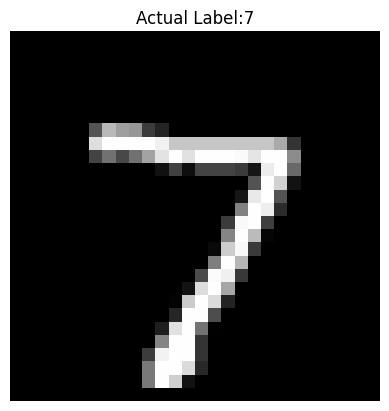

User Picked Index 0
Actual Label 7
Model Prediction:7


In [8]:
index = 0
image_tensor, true_label = test_data[index]
plt.imshow(image_tensor.squeeze(), cmap="gray")
plt.title(f"Actual Label:{true_label}")
plt.axis('off')
plt.show()
image_flat = image_tensor.view(1,-1).to(device)
with torch.no_grad():
  output = model(image_flat)
  predicted_label = output.argmax(dim=1).item()
  print("User Picked Index",index)
  print("Actual Label",true_label)
  print(f"Model Prediction:{predicted_label}")

Using CNN

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torch.utils.data import Dataset, DataLoader

In [4]:
torch.manual_seed(42)

In [5]:
df = pd.read_csv("fmnist_small.csv")

print(df.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      9       0       0       0       0       0       0       0       0   
1      7       0       0       0       0       0       0       0       0   
2      0       0       0       0       0       0       1       0       0   
3      8       0       0       0       0       0       0       0       0   
4      8       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         7         0        50       205       196   
1       0  ...         0         0         0         0         0         0   
2       0  ...       142       142       142        21         0         3   
3       0  ...         0         0         0         0         0         0   
4       0  ...       213       203       174       151       188        10   

   pixel781  pixel782  pixel783  pixel784  
0       213       165         

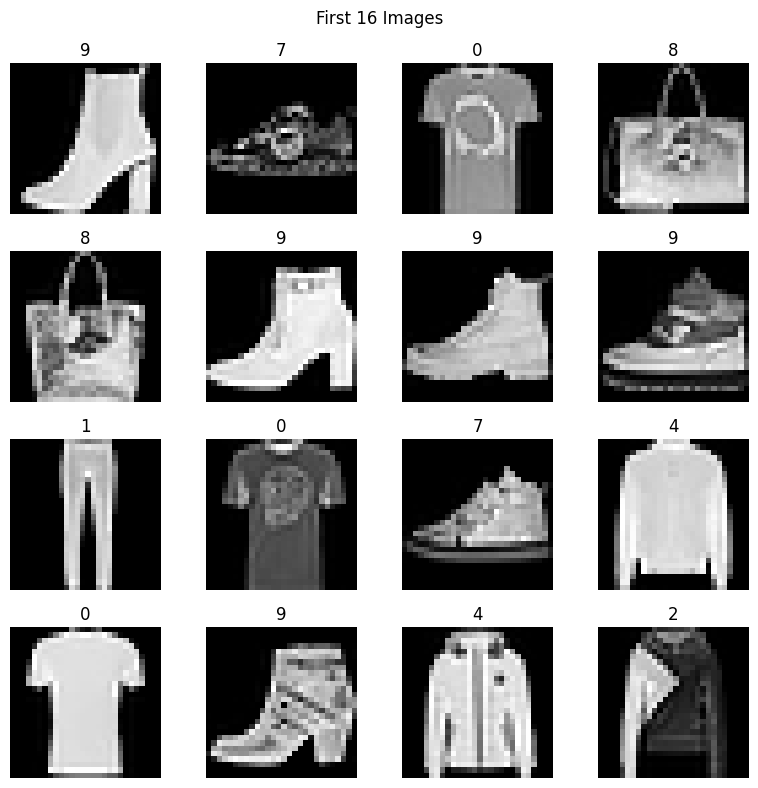

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("First 16 Images")

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(df.iloc[i, 0])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
X = X / 255.0

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


train_dataset = CustomDataset(x_train, y_train)
test_dataset = CustomDataset(x_test, y_test)

train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          shuffle=True)

test_loader = DataLoader(test_dataset,
                         batch_size=32,
                         shuffle=False)

In [10]:
class MyNN(nn.Module):

    def __init__(self, num_features):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(num_features, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)

        )

    def forward(self, x):
        return self.network(x)

In [11]:
model = MyNN(x_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30

loss_history = []
train_accuracy = []

In [12]:
for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for features, labels in train_loader:

        outputs = model(features)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)

    acc = 100 * correct / total

    loss_history.append(avg_loss)

    train_accuracy.append(acc)

    print(
        f"Epoch {epoch+1}/{epochs} | Loss={avg_loss:.4f} | Accuracy={acc:.2f}%"
    )


Epoch 1/30 | Loss=1.0503 | Accuracy=61.90%
Epoch 2/30 | Loss=0.6295 | Accuracy=76.69%
Epoch 3/30 | Loss=0.5470 | Accuracy=80.40%
Epoch 4/30 | Loss=0.5086 | Accuracy=81.19%
Epoch 5/30 | Loss=0.4407 | Accuracy=84.27%
Epoch 6/30 | Loss=0.4126 | Accuracy=85.12%
Epoch 7/30 | Loss=0.3838 | Accuracy=85.81%
Epoch 8/30 | Loss=0.3637 | Accuracy=86.65%
Epoch 9/30 | Loss=0.3448 | Accuracy=87.00%
Epoch 10/30 | Loss=0.3182 | Accuracy=88.04%
Epoch 11/30 | Loss=0.2970 | Accuracy=88.69%
Epoch 12/30 | Loss=0.2870 | Accuracy=89.44%
Epoch 13/30 | Loss=0.2720 | Accuracy=89.96%
Epoch 14/30 | Loss=0.2581 | Accuracy=90.58%
Epoch 15/30 | Loss=0.2481 | Accuracy=90.77%
Epoch 16/30 | Loss=0.2446 | Accuracy=90.92%
Epoch 17/30 | Loss=0.2176 | Accuracy=92.23%
Epoch 18/30 | Loss=0.2137 | Accuracy=92.48%
Epoch 19/30 | Loss=0.2036 | Accuracy=92.85%
Epoch 20/30 | Loss=0.1983 | Accuracy=92.98%
Epoch 21/30 | Loss=0.1912 | Accuracy=93.31%
Epoch 22/30 | Loss=0.1735 | Accuracy=94.00%
Epoch 23/30 | Loss=0.1754 | Accuracy=93.6

In [13]:
torch.save(model.state_dict(), "fashion_model.pth")
print("\nModel Saved Successfully")


Model Saved Successfully


In [14]:
model.load_state_dict(torch.load("fashion_model.pth"))
model.eval()

MyNN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [15]:
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for features, labels in test_loader:

        outputs = model(features)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.numpy())

        all_labels.extend(labels.numpy())

test_accuracy = 100 * correct / total

print("\nTest Accuracy:", test_accuracy)


Test Accuracy: 83.83333333333333


In [16]:
print("\nClassification Report\n")
print(classification_report(all_labels, all_predictions))


Classification Report

              precision    recall  f1-score   support

           0       0.84      0.65      0.73       146
           1       0.93      0.94      0.93       122
           2       0.84      0.76      0.80       119
           3       0.84      0.81      0.82       126
           4       0.72      0.86      0.78       137
           5       0.96      0.87      0.91       113
           6       0.63      0.72      0.67       128
           7       0.88      0.95      0.91       111
           8       0.96      0.95      0.96       111
           9       0.92      0.95      0.94        87

    accuracy                           0.84      1200
   macro avg       0.85      0.85      0.85      1200
weighted avg       0.84      0.84      0.84      1200



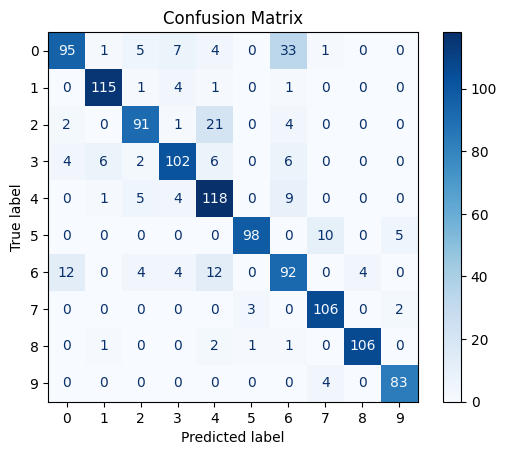

In [17]:
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

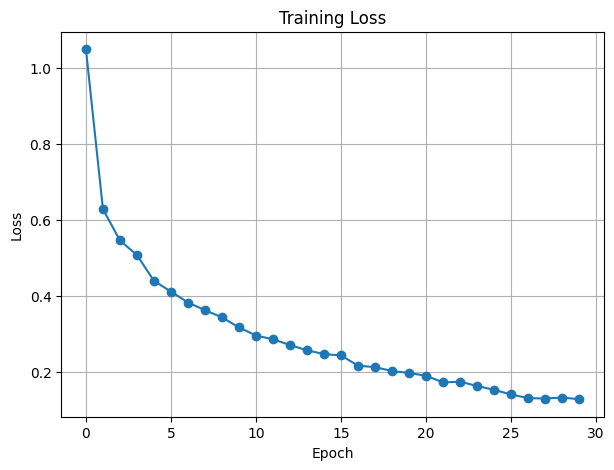

In [18]:
plt.figure(figsize=(7,5))

plt.plot(loss_history, marker="o")

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

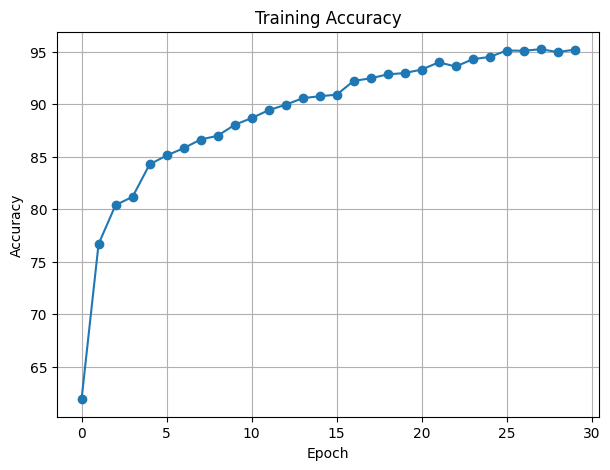

In [19]:
plt.figure(figsize=(7,5))

plt.plot(train_accuracy, marker="o")

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid()

plt.show()


Actual Label : 8
Predicted Label : 4


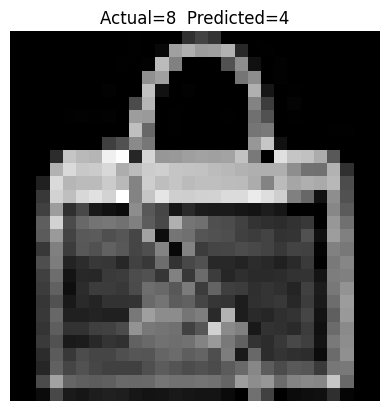

In [20]:
index = 5

image = x_test[index]

image_tensor = torch.tensor(
    image,
    dtype=torch.float32
).unsqueeze(0)

with torch.no_grad():

    output = model(image_tensor)

    prediction = torch.argmax(output, 1).item()

print("\nActual Label :", y_test[index])
print("Predicted Label :", prediction)

plt.imshow(image.reshape(28, 28), cmap="gray")

plt.title(
    f"Actual={y_test[index]}  Predicted={prediction}"
)

plt.axis("off")

plt.show()